# Predicting Sharjah Traffic: A Least Squares Approach
**Course:** MATH 101

## 1. The Overdetermined System
When mapping traffic congestion percentages ($y$) against time ($X$), we have hundreds of hourly observations but only a few temporal variables. This creates a system of linear equations:
$$X\beta = y$$
Because $X$ is a tall, rectangular matrix and real-world traffic contains variance, the vector $y$ does not sit perfectly in the column space of $X$. The system is **inconsistent** and has no exact solution.

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load and melt the dataset
df = pd.read_csv("sharjah_congestion.csv")
days = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
data = [{"hour": row["Hour"], "weekday": day, "congestion": row[day]}
        for i, row in df.iterrows() for day in days]
data = pd.DataFrame(data)

## 2. Bending the Matrix (Harmonics & Interactions)
To allow our line of best fit to trace the sharp morning and evening traffic spikes, we map time onto a unit circle and add higher-frequency Fourier harmonics.
We also multiply these waves by a binary variable ($1$ for weekdays, $0$ for weekends) so the matrix calculates different curves for workdays.

Features included in $X$:
* **Base Waves:** $\sin(2\pi \frac{h}{24})$, $\sin(4\pi \frac{h}{24})$, $\sin(6\pi \frac{h}{24})$
* **Interaction Terms:** $W \cdot \sin(2\pi \frac{h}{24})$

In [9]:
x, y = [], []
for i, row in data.iterrows():
    h, d = row["hour"], row["weekday"]

    # Waves
    sin24, cos24 = np.sin(2*np.pi*h/24), np.cos(2*np.pi*h/24)
    sin12, cos12 = np.sin(4*np.pi*h/24), np.cos(4*np.pi*h/24)
    sin8, cos8 = np.sin(6*np.pi*h/24), np.cos(6*np.pi*h/24)

    # Weekday Interaction
    wd = 1 if d in ["Mon", "Tue", "Wed", "Thu", "Fri"] else 0

    # Dummy Variables
    inds = [1 if d==day else 0 for day in ["Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]]

    features = [1, sin24, cos24, sin12, cos12, sin8, cos8,
                sin24*wd, cos24*wd, sin12*wd, cos12*wd, sin8*wd, cos8*wd] + inds
    x.append(features)
    y.append(row["congestion"])

X = np.array(x)
Y = np.array(y)

# Let's look at the shape of our Design Matrix
print(f"Matrix X shape: {X.shape} (Observations x Features)")

Matrix X shape: (168, 19) (Observations x Features)


## 3. The Normal Equations
To find the closest approximation $\hat{\beta}$ that minimizes the squared errors, we project $y$ onto the column space of $X$ by multiplying both sides by the transpose, $X^T$.

$$X^T X \hat{\beta} = X^T y$$
This transforms the impossible system into a solvable, square system. We isolate the optimal coefficients:
$$\hat{\beta} = (X^T X)^{-1} X^T y$$

RMSE: 8.30%


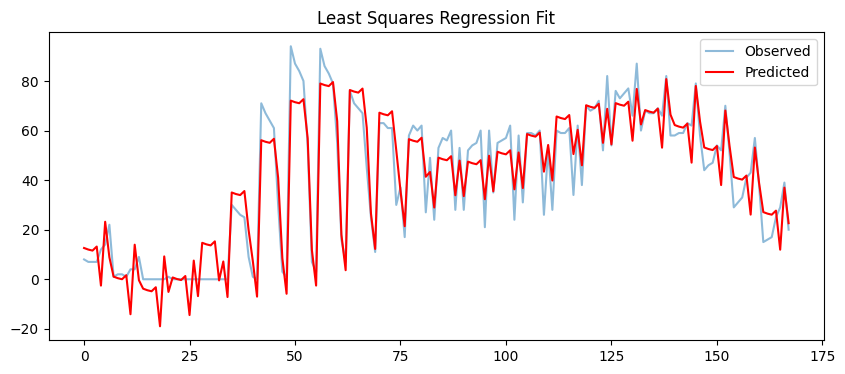

In [10]:
# The Linear Algebra Core
XT = X.T
beta = np.linalg.inv(XT @ X) @ XT @ Y

# Predictions and Error
y_pred = X @ beta
rmse = np.sqrt(np.mean((Y - y_pred)**2))
print(f"RMSE: {rmse:.2f}%")

plt.figure(figsize=(10, 4))
plt.plot(Y, label="Observed", alpha=0.5)
plt.plot(y_pred, label="Predicted", color='red')
plt.title("Least Squares Regression Fit")
plt.legend()
plt.show()